# Brain Tumor — Phase 3 Deep Learning Benchmark

## Tier 0: Pure CNN · Tier 1: Hybrids · Tier 2: Fusion

### Workflow (per-model freedom)

1. Run **Sections 0–5** once (setup → training utilities).
2. Open the **train cell** for one model (Section 6–8).
3. Edit **`ARCH`** (layers, dropout, embed sizes) and **`RUN_SPLIT` / `RUN_CV`**.
4. Run **only that cell** — outputs go to `cache/.../phase3_dl/<hash>/` and `results/`.
5. After training several models, run **Section 9** to merge metrics.

Optional: replace `build_fn` in a train cell with your own `nn.Module` for full custom architectures.

**Resume:** re-run the same train cell after Kernel → Interrupt (checkpoint per epoch).

**Artifacts:** `cache/brain_tumor/phase_artifacts/phase3_dl/`, `results/phase3_*.csv`, `figures/phase3_*.png`


## Section 0 — Setup

In [23]:
%pip install -q torch torchvision timm scikit-learn tqdm pillow \
    numpy pandas matplotlib seaborn scikit-image pywavelets joblib


Note: you may need to restart the kernel to use updated packages.


In [24]:
import hashlib, json, time, warnings
from datetime import datetime, timezone
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
try:
    from torch.amp import GradScaler, autocast
    def _autocast():
        return autocast("cuda", enabled=USE_AMP)
except ImportError:
    from torch.cuda.amp import GradScaler, autocast
    def _autocast():
        return autocast(enabled=USE_AMP)

import torchvision
from torchvision import transforms

from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.filters import gaussian
from skimage import exposure
from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops
import pywt

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

sns.set_theme(style="whitegrid", font_scale=1.05)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
scaler = GradScaler(enabled=USE_AMP)
print("Device:", DEVICE)
print("Mixed precision:", USE_AMP)


Device: cuda
Mixed precision: True


## Section 1 — Configuration & Phase 1 handoff

In [25]:
# ── Paths (edit DATASET_ROOT if your local layout differs) ─────────────────
CANDIDATE_DATASET_ROOTS = [
    Path("Dataset-20260515T090034Z-3-001/Dataset/BrainTumorDetection&Classification/BrainTumorDetection&Classification"),
    Path("Dataset/BrainTumorDetection&Classification/BrainTumorDetection&Classification"),
]
DATASET_ROOT = next((p for p in CANDIDATE_DATASET_ROOTS if (p / "images_by_class").is_dir()), CANDIDATE_DATASET_ROOTS[0])
DATASET_DIR = DATASET_ROOT / "images_by_class"

TARGET_SIZE = (128, 128)
USE_CLAHE = True
TEST_SIZE = 0.20
VAL_FRAC_OF_TRAIN = 0.125  # ~70/10/20 overall
MAX_SAMPLES_PER_CLASS = None

CACHE_DIR = Path("cache/brain_tumor")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
PHASE_CACHE_DIR = CACHE_DIR / "phase_artifacts"
PHASE3_CACHE_DIR = PHASE_CACHE_DIR / "phase3_dl"
PHASE3_CACHE_DIR.mkdir(parents=True, exist_ok=True)
FORCE_RECOMPUTE_CACHE = False
USE_PHASE3_CACHE = True

PHASE1_BEST_JSON = PHASE_CACHE_DIR / "phase1_best.json"
RESULTS_DIR = Path("results")
FIGURES_DIR = Path("figures")
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# Training hyperparameters
MAX_EPOCHS = 30
EARLY_STOP_PATIENCE = 5
BATCH_SIZE_TIER0 = 16
BATCH_SIZE_HYBRID = 16
BATCH_SIZE_FUSION = 8
BATCH_SIZE_VIT = 8
LR_TIER0 = 1e-4
LR_HYBRID = 1e-3
CV_FOLDS = 5
GRAD_CLIP_NORM = 1.0

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

TRAINING_HPARAMS = {
    "seed": SEED, "max_epochs": MAX_EPOCHS, "early_stop_patience": EARLY_STOP_PATIENCE,
    "lr_tier0": LR_TIER0, "lr_hybrid": LR_HYBRID, "grad_clip_norm": GRAD_CLIP_NORM,
    "use_amp": USE_AMP,
}


def load_phase1_best(path=PHASE1_BEST_JSON):
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Run Phase 1 in Projet7_brainTumorDetection.ipynb first."
        )
    handoff = json.loads(path.read_text(encoding="utf-8"))
    best = handoff["best"]
    g = {}
    G, L, D, H = best["GLCM"], best["LBP"], best["DWT"], best["HOG"]
    g["BEST_GLCM_DIST"] = G["distances"]
    g["BEST_GLCM_ANG"] = G["angles"]
    g["BEST_GLCM_LVL"] = int(G["levels"])
    g["BEST_GLCM_SYM"] = bool(G["symmetric"])
    g["BEST_LBP_P"] = int(L["P"])
    g["BEST_LBP_R"] = int(L["R"])
    g["BEST_LBP_METHOD"] = str(L["method"])
    g["BEST_DWT_WAV"] = str(D["wavelet"])
    g["BEST_DWT_LEVEL"] = int(D["level"])
    g["BEST_HOG_ORI"] = int(H["orientations"])
    g["BEST_HOG_PPC"] = tuple(H["pixels_per_cell"])
    g["BEST_HOG_CPB"] = tuple(H["cells_per_block"])
    g["BEST_HOG_NORM"] = str(H["block_norm"])
    g["phase1_run_id"] = handoff.get("phase1_run_id", "unknown")
    return g


_phase1 = load_phase1_best()
globals().update(_phase1)
print("Loaded Phase 1 optimal parameters from", PHASE1_BEST_JSON)
print(f"  GLCM distances={BEST_GLCM_DIST}  LBP P={BEST_LBP_P} R={BEST_LBP_R}")
print(f"  DWT {BEST_DWT_WAV} level={BEST_DWT_LEVEL}  HOG ori={BEST_HOG_ORI}")


Loaded Phase 1 optimal parameters from cache\brain_tumor\phase_artifacts\phase1_best.json
  GLCM distances=[1, 2, 4, 8]  LBP P=8 R=1
  DWT bior1.3 level=1  HOG ori=6


## Section 2 — Dataset load & train / val / test splits

In [26]:
def crop_black(img, thr=0.05):
    mask = img > thr
    if not np.any(mask):
        return img
    ys, xs = np.where(mask)
    return img[ys.min() : ys.max() + 1, xs.min() : xs.max() + 1]


def preprocess_mri(img):
    if img.ndim == 3:
        img = rgb2gray(img)
    img = img.astype(np.float32)
    if img.max() > 1.0:
        img /= 255.0
    img = crop_black(img)
    img = resize(img, TARGET_SIZE, anti_aliasing=True, preserve_range=True).astype(np.float32)
    img = gaussian(img, sigma=0.5, preserve_range=True).astype(np.float32)
    mn, mx = img.min(), img.max()
    img = (img - mn) / (mx - mn + 1e-9)
    if USE_CLAHE:
        img = np.clip(exposure.equalize_adapthist(img, clip_limit=0.02), 0, 1)
    return img.astype(np.float32)


def load_dataset(dataset_dir, max_per_class=None):
    class_names = sorted([d.name for d in dataset_dir.iterdir() if d.is_dir()])
    rng = np.random.default_rng(SEED)
    X_list, y_list = [], []
    for idx, cls in enumerate(class_names):
        paths = [
            p
            for p in (dataset_dir / cls).iterdir()
            if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        ]
        if max_per_class and len(paths) > max_per_class:
            paths = [paths[i] for i in rng.choice(len(paths), max_per_class, replace=False)]
        for p in tqdm(paths, desc=f"  {cls}"):
            try:
                X_list.append(preprocess_mri(imread(p)))
                y_list.append(idx)
            except Exception:
                pass
    return np.stack(X_list).astype(np.float32), np.array(y_list, np.int32), class_names


cache_tag = f"sz{TARGET_SIZE[0]}x{TARGET_SIZE[1]}_clahe{int(USE_CLAHE)}_test{TEST_SIZE}_max{MAX_SAMPLES_PER_CLASS}"
cache_hash = hashlib.md5(cache_tag.encode("utf-8")).hexdigest()[:10]
dataset_cache_path = CACHE_DIR / f"dataset_{cache_hash}.npz"

if dataset_cache_path.exists() and not FORCE_RECOMPUTE_CACHE:
    print(f"Loading dataset from cache: {dataset_cache_path}")
    ds = np.load(dataset_cache_path, allow_pickle=True)
    X_train_pool = ds["X_train_raw"]
    X_test = ds["X_test_raw"]
    y_train_pool = ds["y_train"]
    y_test = ds["y_test"]
    class_names = list(ds["class_names"])
else:
    if not DATASET_DIR.is_dir():
        raise FileNotFoundError(f"Dataset not found: {DATASET_DIR}")
    print("Loading dataset from images …")
    X_all, y_all, class_names = load_dataset(DATASET_DIR, MAX_SAMPLES_PER_CLASS)
    X_train_pool, X_test, y_train_pool, y_test = train_test_split(
        X_all, y_all, test_size=TEST_SIZE, random_state=SEED, stratify=y_all
    )
    np.savez_compressed(
        dataset_cache_path,
        X_train_raw=X_train_pool,
        X_test_raw=X_test,
        y_train=y_train_pool,
        y_test=y_test,
        class_names=np.array(class_names, dtype=object),
    )
    print(f"Saved dataset cache: {dataset_cache_path}")

# Val split from train pool (same ratio as VLM)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_pool,
    y_train_pool,
    test_size=VAL_FRAC_OF_TRAIN,
    random_state=SEED,
    stratify=y_train_pool,
)

n_classes = len(class_names)
X_train_pool_raw = np.concatenate([X_train, X_val], axis=0)
y_train_pool = np.concatenate([y_train, y_val], axis=0)
class_weights = torch.tensor(
    compute_class_weight('balanced', classes=np.arange(n_classes), y=y_train),
    dtype=torch.float32,
).to(DEVICE)
print(f"Classes: {class_names}")
print(f"Train {X_train.shape}  Val {X_val.shape}  Test {X_test.shape}")


Loading dataset from cache: cache\brain_tumor\dataset_3a3180af56.npz
Classes: ['Glioma', 'Meningioma', 'Pituitary Tumor']
Train (1050, 128, 128)  Val (150, 128, 128)  Test (300, 128, 128)


## Section 3 — Handcrafted features (Phase 1 optimal params)

In [27]:
def extract_glcm(images, distances, angles, levels, symmetric):
    props = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"]
    rows = []
    for img in images:
        q = np.clip(np.floor(img * levels), 0, levels - 1).astype(np.uint8)
        glcm = graycomatrix(
            q,
            distances=distances,
            angles=angles,
            levels=levels,
            symmetric=symmetric,
            normed=True,
        )
        rows.append([graycoprops(glcm, p).mean() for p in props])
    return np.array(rows, dtype=np.float32)


def extract_lbp(images, P, R, method):
    MAX_LBP_BINS = 4096
    if method in ("uniform", "nri_uniform"):
        n_bins = P + 2
        hist_range = (0, n_bins)
    else:
        full_bins = 2 ** P
        n_bins = min(full_bins, MAX_LBP_BINS)
        hist_range = (0, full_bins)
    rows = []
    for img in images:
        lbp = local_binary_pattern(img, P=P, R=R, method=method)
        hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=hist_range, density=True)
        rows.append(hist.astype(np.float32))
    return np.array(rows, dtype=np.float32)


def _band_stats(b):
    v = b.ravel().astype(np.float32)
    h, _ = np.histogram(v, bins=64, density=True)
    h = (h + 1e-12)
    h /= h.sum()
    return [v.mean(), v.std(), np.mean(v ** 2), -(h * np.log2(h)).sum()]


def extract_dwt(images, wavelet, level):
    rows = []
    for img in images:
        coeffs = pywt.wavedec2(img, wavelet=wavelet, level=level)
        feats = _band_stats(coeffs[0])
        for detail_tuple in coeffs[1:]:
            for band in detail_tuple:
                feats.extend(_band_stats(band))
        rows.append(np.array(feats, np.float32))
    return np.array(rows, dtype=np.float32)


def feat_stats(img):
    v = img.ravel()
    h, _ = np.histogram(v, bins=64, range=(0, 1), density=True)
    h = (h + 1e-12)
    h /= h.sum()
    p10, p25, p50, p75, p90 = np.percentile(v, [10, 25, 50, 75, 90])
    return np.array(
        [
            v.mean(),
            v.std(),
            v.var(),
            -(h * np.log2(h)).sum(),
            skew(v),
            kurtosis(v),
            p10,
            p25,
            p50,
            p75,
            p90,
        ],
        np.float32,
    )


def feat_hog(img):
    return hog(
        img,
        orientations=BEST_HOG_ORI,
        pixels_per_cell=tuple(BEST_HOG_PPC),
        cells_per_block=tuple(BEST_HOG_CPB),
        block_norm=BEST_HOG_NORM,
        feature_vector=True,
    ).astype(np.float32)


feature_cache_tag = (
    f"feat_glcm{BEST_GLCM_DIST}_{BEST_GLCM_ANG}_{BEST_GLCM_LVL}_{int(BEST_GLCM_SYM)}"
    f"_lbp{BEST_LBP_P}_{BEST_LBP_R}_{BEST_LBP_METHOD}_dwt{BEST_DWT_WAV}_{BEST_DWT_LEVEL}"
    f"_hog{BEST_HOG_ORI}_{tuple(BEST_HOG_PPC)}_{tuple(BEST_HOG_CPB)}_{BEST_HOG_NORM}"
    "_dl_splits_v1"  # train/val/test/pool layout (distinct from Projet7 B_glcm_tr keys)
)
feature_cache_hash = hashlib.md5(feature_cache_tag.encode("utf-8")).hexdigest()[:10]
feature_cache_path = CACHE_DIR / f"features_{feature_cache_hash}.npz"

X_train_pool_raw = np.concatenate([X_train, X_val], axis=0)
y_train_pool = np.concatenate([y_train, y_val], axis=0)

REQUIRED_HC_KEYS = [
    f"{branch}_{split}"
    for branch in ("A", "glcm", "lbp", "dwt", "hog")
    for split in ("train", "val", "test", "pool")
]


def hc_is_complete(hc):
    return hc is not None and all(k in hc for k in REQUIRED_HC_KEYS)


def _fill_split(HC, split_name, Xs):
    print(f"  split={split_name}  (n={len(Xs)})")
    HC[f"A_{split_name}"] = np.vstack([feat_stats(x) for x in tqdm(Xs, leave=False)])
    HC[f"glcm_{split_name}"] = extract_glcm(
        Xs, BEST_GLCM_DIST, BEST_GLCM_ANG, BEST_GLCM_LVL, BEST_GLCM_SYM
    )
    HC[f"lbp_{split_name}"] = extract_lbp(Xs, BEST_LBP_P, BEST_LBP_R, BEST_LBP_METHOD)
    HC[f"dwt_{split_name}"] = extract_dwt(Xs, BEST_DWT_WAV, BEST_DWT_LEVEL)
    HC[f"hog_{split_name}"] = np.vstack([feat_hog(x) for x in tqdm(Xs, leave=False)])


# Legacy Projet7 Phase 2 cache: B_glcm_tr, C_tr, D_tr, A_tr, *_te (80/20 only)
LEGACY_TEST_MAP = {
    "A": "A_te", "glcm": "B_glcm_te", "lbp": "B_lbp_te",
    "dwt": "C_te", "hog": "D_te",
}

HC = None
legacy_ft = None
if feature_cache_path.exists() and not FORCE_RECOMPUTE_CACHE:
    legacy_ft = np.load(feature_cache_path)
    HC = {k: legacy_ft[k] for k in legacy_ft.files}
    if hc_is_complete(HC):
        print(f"Loading features from cache: {feature_cache_path}")
    else:
        if "B_glcm_tr" in HC or "B_glcm_te" in HC:
            print(
                f"Legacy Phase 2 layout in {feature_cache_path.name} "
                "(B_glcm_tr / C_tr / …) — rebuilding train/val/test/pool for Deep_learning …"
            )
        else:
            print(f"Incomplete cache {feature_cache_path.name} — rebuilding …")
        HC = {}

if not hc_is_complete(HC):
    print("Extracting handcrafted features …")
    if HC is None:
        HC = {}
    for split_name, Xs in [
        ("train", X_train),
        ("val", X_val),
        ("pool", X_train_pool_raw),
    ]:
        _fill_split(HC, split_name, Xs)

    reuse_test = False
    if legacy_ft is not None and "B_glcm_te" in legacy_ft.files:
        if legacy_ft["B_glcm_te"].shape[0] == len(X_test):
            reuse_test = True
            print(f"  split=test  (n={len(X_test)}) — reusing legacy *_te arrays")
            for branch, legacy_key in LEGACY_TEST_MAP.items():
                HC[f"{branch}_test"] = legacy_ft[legacy_key]
    if not reuse_test:
        _fill_split(HC, "test", X_test)

    np.savez_compressed(feature_cache_path, **HC)
    print(f"Saved feature cache: {feature_cache_path}")

HAND_DIMS = {
    "glcm": HC["glcm_train"].shape[1],
    "lbp": HC["lbp_train"].shape[1],
    "dwt": HC["dwt_train"].shape[1],
    "hog": HC["hog_train"].shape[1],
    "stats": HC["A_train"].shape[1],
}
print("Handcrafted dimensions:", HAND_DIMS)


Loading features from cache: cache\brain_tumor\features_85359985a4.npz
Handcrafted dimensions: {'glcm': 6, 'lbp': 10, 'dwt': 16, 'hog': 1944, 'stats': 11}


## Section 4 — PyTorch datasets & model definitions


In [28]:
def gray_to_tensor(img):
    """(H,W) float [0,1] -> (3,H,W) tensor."""
    t = torch.from_numpy(img).unsqueeze(0).repeat(3, 1, 1)
    return t


train_img_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_img_tf = transforms.Compose([
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class MRIDataset(Dataset):
    def __init__(self, X_img, y, hand=None, train=False, vit_size=224):
        self.X = X_img
        self.y = y
        self.hand = hand
        self.train = train
        self.vit_size = vit_size

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        img = gray_to_tensor(self.X[idx])
        if self.vit_size and self.vit_size != img.shape[-1]:
            img = F.interpolate(
                img.unsqueeze(0),
                size=(self.vit_size, self.vit_size),
                mode="bilinear",
                align_corners=False,
            ).squeeze(0)
        if self.train:
            img = train_img_tf(img)
        else:
            img = eval_img_tf(img)
        y = int(self.y[idx])
        if self.hand is None:
            return img, y
        if len(self.hand) == 1:
            arr = next(iter(self.hand.values()))
            h = torch.from_numpy(arr[idx].astype(np.float32))
            return img, h, y
        h = {k: torch.from_numpy(v[idx].astype(np.float32)) for k, v in self.hand.items()}
        return img, h, y


def _mlp_head(in_dim, n_classes, dropout=0.3, hidden=None):
    """Classifier head — edit hidden/dropout via ARCH in train cells."""
    if hidden is None:
        return nn.Sequential(nn.Dropout(dropout), nn.Linear(in_dim, n_classes))
    return nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_dim, hidden),
        nn.ReLU(),
        nn.Dropout(dropout * 0.5),
        nn.Linear(hidden, n_classes),
    )


def _replace_classifier(backbone, in_dim, n_classes, dropout=0.3):
    if hasattr(backbone, "fc"):
        backbone.fc = _mlp_head(in_dim, n_classes, dropout=dropout)
    elif hasattr(backbone, "classifier"):
        if isinstance(backbone.classifier, nn.Sequential):
            backbone.classifier = _mlp_head(in_dim, n_classes, dropout=dropout)
        else:
            backbone.classifier = nn.Linear(in_dim, n_classes)
    elif hasattr(backbone, "heads"):
        backbone.heads.head = _mlp_head(in_dim, n_classes, dropout=dropout)
    return backbone


def encode_resnet18(backbone, x):
    x = backbone.conv1(x)
    x = backbone.bn1(x)
    x = backbone.relu(x)
    x = backbone.maxpool(x)
    x = backbone.layer1(x)
    x = backbone.layer2(x)
    x = backbone.layer3(x)
    x = backbone.layer4(x)
    x = backbone.avgpool(x)
    return torch.flatten(x, 1)


def build_resnet18(n_classes=3, pretrained=True):
    w = torchvision.models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    m = torchvision.models.resnet18(weights=w)
    in_dim = m.fc.in_features
    m.fc = nn.Identity()
    return m, in_dim


def build_tier0(model_id, n_classes=3):
    if model_id == "vgg16":
        w = torchvision.models.VGG16_Weights.IMAGENET1K_V1
        m = torchvision.models.vgg16(weights=w)
        in_dim = 512 * 7 * 7
        m.classifier = nn.Identity()
        return m, in_dim, 128
    if model_id == "resnet50":
        w = torchvision.models.ResNet50_Weights.IMAGENET1K_V1
        m = torchvision.models.resnet50(weights=w)
        in_dim = m.fc.in_features
        m.fc = nn.Identity()
        return m, in_dim, 128
    if model_id == "efficientnet_b0":
        w = torchvision.models.EfficientNet_B0_Weights.IMAGENET1K_V1
        m = torchvision.models.efficientnet_b0(weights=w)
        in_dim = m.classifier[1].in_features
        m.classifier = nn.Identity()
        return m, in_dim, 128
    if model_id == "vit_b_16":
        w = torchvision.models.ViT_B_16_Weights.IMAGENET1K_V1
        m = torchvision.models.vit_b_16(weights=w)
        in_dim = m.heads.head.in_features
        m.heads.head = nn.Identity()
        return m, in_dim, 224
    raise ValueError(model_id)


class Tier0Classifier(nn.Module):
    def __init__(self, backbone, feat_dim, n_classes, dropout=0.3, head_hidden=None):
        super().__init__()
        self.backbone = backbone
        self.head = _mlp_head(feat_dim, n_classes, dropout=dropout, hidden=head_hidden)

    def _encode(self, x):
        b = self.backbone
        if hasattr(b, "features"):
            x = b.features(x)
            if hasattr(b, "avgpool"):
                x = b.avgpool(x)
            return torch.flatten(x, 1)
        return b(x)

    def forward(self, x):
        return self.head(self._encode(x))


class HybridClassifier(nn.Module):
    def __init__(self, backbone, feat_dim, hand_dim, n_classes,
                 hand_embed=128, hand_hidden=None, dropout=0.3, head_hidden=None):
        super().__init__()
        self.backbone = backbone
        self.feat_dim = feat_dim
        hand_layers = [nn.Linear(hand_dim, hand_embed), nn.ReLU(), nn.Dropout(0.2)]
        if hand_hidden:
            hand_layers = [
                nn.Linear(hand_dim, hand_hidden), nn.ReLU(), nn.Dropout(0.2),
                nn.Linear(hand_hidden, hand_embed), nn.ReLU(), nn.Dropout(0.2),
            ]
        self.hand_mlp = nn.Sequential(*hand_layers)
        self.head = _mlp_head(feat_dim + hand_embed, n_classes, dropout=dropout, hidden=head_hidden)

    def forward(self, x, h):
        e_img = encode_resnet18(self.backbone, x)
        e_hand = self.hand_mlp(h)
        return self.head(torch.cat([e_img, e_hand], dim=1))


class MultiBranchFusion(nn.Module):
    def __init__(self, backbone, feat_dim, branch_dims, n_classes,
                 embed=64, stats_dim=11, branch_hidden=None, dropout=0.3, head_hidden=None):
        super().__init__()
        self.backbone = backbone
        self.branches = nn.ModuleDict()
        for name, d in branch_dims.items():
            layers = [nn.Linear(d, embed), nn.ReLU(), nn.Dropout(0.2)]
            if branch_hidden:
                layers = [
                    nn.Linear(d, branch_hidden), nn.ReLU(), nn.Dropout(0.2),
                    nn.Linear(branch_hidden, embed), nn.ReLU(), nn.Dropout(0.2),
                ]
            self.branches[name] = nn.Sequential(*layers)
        self.stats_mlp = nn.Sequential(nn.Linear(stats_dim, 32), nn.ReLU())
        fusion_in = feat_dim + embed * len(branch_dims) + 32
        self.head = _mlp_head(fusion_in, n_classes, dropout=dropout, hidden=head_hidden)

    def forward(self, x, hdict):
        parts = [encode_resnet18(self.backbone, x)]
        for name, mlp in self.branches.items():
            parts.append(mlp(hdict[name]))
        parts.append(self.stats_mlp(hdict["stats"]))
        return self.head(torch.cat(parts, dim=1))


class AttentionFusion(nn.Module):
    def __init__(self, backbone, feat_dim, branch_dims, n_classes,
                 embed=64, stats_dim=11, attn_hidden=None, dropout=0.3, head_hidden=None):
        super().__init__()
        self.backbone = backbone
        self.embed = embed
        self.branch_names = list(branch_dims.keys())
        self.encoders = nn.ModuleDict({
            name: nn.Sequential(nn.Linear(d, embed), nn.ReLU())
            for name, d in branch_dims.items()
        })
        n_br = len(self.branch_names)
        attn_in = embed * n_br
        if attn_hidden:
            self.attn = nn.Sequential(
                nn.Linear(attn_in, attn_hidden), nn.ReLU(),
                nn.Linear(attn_hidden, n_br),
            )
        else:
            self.attn = nn.Linear(attn_in, n_br)
        self.stats_mlp = nn.Sequential(nn.Linear(stats_dim, 32), nn.ReLU())
        fusion_in = feat_dim + embed + 32
        self.head = _mlp_head(fusion_in, n_classes, dropout=dropout, hidden=head_hidden)

    def forward(self, x, hdict):
        e_img = encode_resnet18(self.backbone, x)
        embs = [self.encoders[n](hdict[n]) for n in self.branch_names]
        stack = torch.stack(embs, dim=1)
        flat = stack.reshape(stack.size(0), -1)
        logits = self.attn(flat) if isinstance(self.attn, nn.Sequential) else self.attn(flat)
        alpha = torch.softmax(logits, dim=1).unsqueeze(-1)
        fused = (stack * alpha).sum(dim=1)
        parts = [e_img, fused, self.stats_mlp(hdict["stats"])]
        return self.head(torch.cat(parts, dim=1))


print("Model classes defined (ARCH kwargs: dropout, head_hidden, hand_embed, embed, …).")


Model classes defined (ARCH kwargs: dropout, head_hidden, hand_embed, embed, …).


## Section 5 — Training utilities (resume, AMP, checkpointing)


In [29]:
PHASE3_MANIFEST = PHASE3_CACHE_DIR / "phase3_manifest.json"
PHASE3_METRICS_ROWS = []


def _cache_key(tier, model_id, eval_mode, fold_id=None):
    tag = f"tier={tier}|model={model_id}|mode={eval_mode}|fold={fold_id}|seed={SEED}|n={len(y_train_pool)}"
    return hashlib.md5(tag.encode("utf-8")).hexdigest()[:12]


def _run_dir(stem):
    d = PHASE3_CACHE_DIR / stem
    d.mkdir(parents=True, exist_ok=True)
    return d


def _load_cached_run(stem):
    """Return summary if this run fully finished (summary + best weights)."""
    summ_p = _run_dir(stem) / "summary.json"
    best_p = _run_dir(stem) / "best_state.pt"
    if not (USE_PHASE3_CACHE and summ_p.exists() and best_p.exists()):
        return None
    summary = json.loads(summ_p.read_text(encoding="utf-8"))
    hist_p = _run_dir(stem) / "history.csv"
    if hist_p.exists():
        summary["history"] = pd.read_csv(hist_p)
    return summary


def _save_hparams(stem, extra=None):
    hp = dict(TRAINING_HPARAMS)
    if extra:
        hp.update(extra)
    (_run_dir(stem) / "hparams.json").write_text(json.dumps(hp, indent=2, default=str), encoding="utf-8")


def _save_completed_run(stem, summary, history_df, state_dict):
    rd = _run_dir(stem)
    torch.save(state_dict, rd / "best_state.pt")
    history_df.to_csv(rd / "history.csv", index=False)
    (rd / "summary.json").write_text(json.dumps(summary, indent=2, default=str), encoding="utf-8")
    ckpt = rd / "checkpoint.pt"
    if ckpt.exists():
        ckpt.unlink()
    man = {"runs": []}
    if PHASE3_MANIFEST.exists():
        try:
            man = json.loads(PHASE3_MANIFEST.read_text(encoding="utf-8"))
        except Exception:
            pass
    man.setdefault("runs", []).append({**summary, "run_dir": str(rd.resolve())})
    PHASE3_MANIFEST.write_text(json.dumps(man, indent=2, default=str), encoding="utf-8")


def _save_resume_checkpoint(stem, payload):
    torch.save(payload, _run_dir(stem) / "checkpoint.pt")


def _load_resume_checkpoint(stem, model, optimizer, scheduler):
    ckpt_p = _run_dir(stem) / "checkpoint.pt"
    if not ckpt_p.exists():
        return [], 1, -1.0, None
    ckpt = torch.load(ckpt_p, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    if scheduler is not None and "scheduler_state" in ckpt:
        scheduler.load_state_dict(ckpt["scheduler_state"])
    if USE_AMP and ckpt.get("scaler_state"):
        scaler.load_state_dict(ckpt["scaler_state"])
    return (
        ckpt.get("history", []),
        int(ckpt.get("epoch", 1)),
        float(ckpt.get("best_f1", -1.0)),
        ckpt.get("best_state"),
    )


@torch.no_grad()
def evaluate_model(model, loader, criterion=None, hybrid=False, fusion=False):
    model.eval()
    ys, preds, loss_sum, n = [], [], 0.0, 0
    for batch in loader:
        if fusion:
            x, hdict, y = batch
            x, y = x.to(DEVICE), y.to(DEVICE)
            hdict = {k: v.to(DEVICE) for k, v in hdict.items()}
            with _autocast():
                logits = model(x, hdict)
        elif hybrid:
            x, h, y = batch
            x, h, y = x.to(DEVICE), h.to(DEVICE), y.to(DEVICE)
            with _autocast():
                logits = model(x, h)
        else:
            x, y = batch
            x, y = x.to(DEVICE), y.to(DEVICE)
            with _autocast():
                logits = model(x)
        if criterion is not None:
            loss_sum += criterion(logits, y).item() * y.size(0)
        n += y.size(0)
        preds.append(logits.argmax(1).cpu().numpy())
        ys.append(y.cpu().numpy())
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(preds)
    metrics = {
        "acc": float(accuracy_score(y_true, y_pred)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
    }
    if criterion is not None:
        metrics["loss"] = loss_sum / max(n, 1)
    return metrics, y_true, y_pred


def _train_step(model, batch, criterion, optimizer, hybrid, fusion):
    optimizer.zero_grad(set_to_none=True)
    if fusion:
        x, hdict, y = batch
        x, y = x.to(DEVICE), y.to(DEVICE)
        hdict = {k: v.to(DEVICE) for k, v in hdict.items()}
        with _autocast():
            logits = model(x, hdict)
            loss = criterion(logits, y)
    elif hybrid:
        x, h, y = batch
        x, h, y = x.to(DEVICE), h.to(DEVICE), y.to(DEVICE)
        with _autocast():
            logits = model(x, h)
            loss = criterion(logits, y)
    else:
        x, y = batch
        x, y = x.to(DEVICE), y.to(DEVICE)
        with _autocast():
            logits = model(x)
            loss = criterion(logits, y)
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
    scaler.step(optimizer)
    scaler.update()
    return loss.item() * y.size(0), y.size(0)


def train_model_with_resume(
    model,
    train_loader,
    val_loader,
    lr,
    stem,
    max_epochs=MAX_EPOCHS,
    patience=EARLY_STOP_PATIENCE,
    hybrid=False,
    fusion=False,
    hparam_extra=None,
):
    model = model.to(DEVICE)
    _save_hparams(stem, hparam_extra)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

    history_list, start_epoch, best_f1, best_state = _load_resume_checkpoint(stem, model, optimizer, scheduler)
    wait = 0
    if history_list:
        last = history_list[-1]
        print(f"  Resuming {stem} from epoch {start_epoch - 1}, best val f1={best_f1:.4f}")
    else:
        start_epoch = 1
        best_f1 = -1.0
        best_state = None

    t0 = time.time()
    epoch = start_epoch - 1
    try:
        for epoch in range(start_epoch, max_epochs + 1):
            model.train()
            running, n_seen = 0.0, 0
            for batch in train_loader:
                loss_val, bs = _train_step(model, batch, criterion, optimizer, hybrid, fusion)
                running += loss_val
                n_seen += bs

            val_m, _, _ = evaluate_model(model, val_loader, hybrid=hybrid, fusion=fusion)
            scheduler.step(val_m["f1_macro"])
            row = {
                "epoch": epoch,
                "train_loss": running / max(n_seen, 1),
                "val_f1_macro": val_m["f1_macro"],
                "val_acc": val_m["acc"],
            }
            history_list.append(row)
            print(
                f"    epoch {epoch:02d}  train_loss={row['train_loss']:.4f}  val_f1={val_m['f1_macro']:.4f}",
                flush=True,
            )

            if val_m["f1_macro"] > best_f1:
                best_f1 = val_m["f1_macro"]
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                wait = 0
            else:
                wait += 1

            _save_resume_checkpoint(stem, {
                "epoch": epoch + 1,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scheduler_state": scheduler.state_dict(),
                "best_f1": best_f1,
                "best_state": best_state,
                "history": history_list,
                "scaler_state": scaler.state_dict() if USE_AMP else None,
            })

            if wait >= patience:
                print(f"    early stop at epoch {epoch} (best val f1={best_f1:.4f})")
                break
    except KeyboardInterrupt:
        print("\n  Interrupted — checkpoint saved. Re-run this cell to resume.")
        _save_resume_checkpoint(stem, {
            "epoch": epoch + 1,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "best_f1": best_f1,
            "best_state": best_state,
            "history": history_list,
            "scaler_state": scaler.state_dict() if USE_AMP else None,
        })
        raise

    fit_time = time.time() - t0
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history_list), fit_time, best_f1


def make_loaders(
    Xtr, ytr, Xva, yva, Xte, yte,
    hand_tr=None, hand_va=None, hand_te=None,
    batch_size=16, vit_size=None,
):
    train_ds = MRIDataset(Xtr, ytr, hand_tr, train=True, vit_size=vit_size)
    val_ds = MRIDataset(Xva, yva, hand_va, train=False, vit_size=vit_size)
    test_ds = MRIDataset(Xte, yte, hand_te, train=False, vit_size=vit_size)
    fusion = hand_tr is not None and isinstance(hand_tr, dict) and len(hand_tr) > 1
    hybrid = hand_tr is not None and not fusion
    kw = dict(batch_size=batch_size, num_workers=0, pin_memory=torch.cuda.is_available())
    return (
        DataLoader(train_ds, shuffle=True, **kw),
        DataLoader(val_ds, shuffle=False, **kw),
        DataLoader(test_ds, shuffle=False, **kw),
        hybrid,
        fusion,
    )


def metrics_row(tier, model_id, eval_mode, fold_id, m, fit_time, extra=None):
    row = {
        "tier": tier,
        "model": model_id,
        "eval_mode": eval_mode,
        "fold": fold_id if fold_id is not None else "",
        "acc": m["acc"],
        "f1_macro": m["f1_macro"],
        "f1_weighted": m.get("f1_weighted", np.nan),
        "precision_macro": m.get("precision_macro", np.nan),
        "recall_macro": m.get("recall_macro", np.nan),
        "fit_time_s": fit_time,
    }
    if extra:
        row.update(extra)
    PHASE3_METRICS_ROWS.append(row)
    return row


def run_split_experiment(tier, model_id, build_fn, lr, batch_size, vit_size=None):
    stem = _cache_key(tier, model_id, "split")
    cached = _load_cached_run(stem)
    if cached is not None:
        print(f"  [DONE] split {model_id}  test_f1={cached.get('test_f1_macro', cached.get('val_f1_macro', float('nan'))):.4f}")
        metrics_row(
            tier, model_id, "split", None,
            {"acc": cached.get("test_acc", cached.get("val_acc")), "f1_macro": cached.get("test_f1_macro", cached.get("val_f1_macro"))},
            cached["fit_time_s"],
        )
        return cached

    model, train_ld, val_ld, test_ld, hybrid, fusion = build_fn()
    model, hist, fit_t, best_val_f1 = train_model_with_resume(
        model, train_ld, val_ld, lr, stem,
        hybrid=hybrid, fusion=fusion,
        hparam_extra={"tier": tier, "model": model_id, "eval_mode": "split", "lr": lr},
    )
    t0 = time.time()
    test_m, y_true, y_pred = evaluate_model(model, test_ld, hybrid=hybrid, fusion=fusion)
    pred_t = time.time() - t0

    pd.DataFrame(confusion_matrix(y_true, y_pred), index=class_names, columns=class_names).to_csv(
        RESULTS_DIR / f"phase3_cm_{tier}_{model_id}_split.csv"
    )
    summary = {
        "tier": tier, "model": model_id, "eval_mode": "split", "fold": "",
        "best_val_f1_macro": float(best_val_f1),
        "test_acc": test_m["acc"], "test_f1_macro": test_m["f1_macro"],
        "fit_time_s": fit_t, "predict_time_s": pred_t,
        "saved_at_utc": datetime.now(timezone.utc).isoformat(),
    }
    _save_completed_run(stem, summary, hist, model.state_dict())
    metrics_row(tier, model_id, "split", None,
                {"acc": test_m["acc"], "f1_macro": test_m["f1_macro"], "f1_weighted": test_m.get("f1_weighted")}, fit_t)
    print(f"  [split] {model_id}  test_f1={test_m['f1_macro']:.4f}  acc={test_m['acc']:.4f}")
    return summary


def run_cv_experiment(tier, model_id, build_fn, lr, batch_size, vit_size=None):
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    fold_metrics = []

    for fold_id, (tr_idx, va_idx) in enumerate(skf.split(X_train_pool_raw, y_train_pool), start=1):
        stem = _cache_key(tier, model_id, "cv5", fold_id)
        cached = _load_cached_run(stem)
        if cached is not None:
            print(f"  [DONE] cv fold {fold_id} {model_id}  val_f1={cached['val_f1_macro']:.4f}")
            fold_metrics.append(cached)
            continue

        model, train_ld, val_ld, _, hybrid, fusion = build_fn(tr_idx=tr_idx, va_idx=va_idx)
        model, hist, fit_t, best_val_f1 = train_model_with_resume(
            model, train_ld, val_ld, lr, stem,
            hybrid=hybrid, fusion=fusion,
            hparam_extra={"tier": tier, "model": model_id, "eval_mode": "cv5", "fold": fold_id, "lr": lr},
        )
        val_m, _, _ = evaluate_model(model, val_ld, hybrid=hybrid, fusion=fusion)
        summary = {
            "tier": tier, "model": model_id, "eval_mode": "cv5", "fold": fold_id,
            "best_val_f1_macro": float(best_val_f1),
            "val_acc": val_m["acc"], "val_f1_macro": val_m["f1_macro"],
            "fit_time_s": fit_t,
            "saved_at_utc": datetime.now(timezone.utc).isoformat(),
        }
        _save_completed_run(stem, summary, hist, model.state_dict())
        fold_metrics.append(summary)
        print(f"  [cv fold {fold_id}] {model_id}  val_f1={val_m['f1_macro']:.4f}")

    f1s = [f["val_f1_macro"] for f in fold_metrics]
    accs = [f["val_acc"] for f in fold_metrics]
    fit_sum = sum(f["fit_time_s"] for f in fold_metrics)
    agg = {"acc": float(np.mean(accs)), "f1_macro": float(np.mean(f1s)),
           "f1_macro_std": float(np.std(f1s)), "acc_std": float(np.std(accs)), "fit_time_s": fit_sum}
    metrics_row(tier, model_id, "cv5_mean", "", agg, fit_sum,
                extra={"f1_macro_std": agg["f1_macro_std"], "acc_std": agg["acc_std"]})
    print(f"  [cv5 mean] {model_id}  f1={agg['f1_macro']:.4f} ± {agg['f1_macro_std']:.4f}")
    return fold_metrics




def train_one_model(
    tier,
    model_id,
    build_fn,
    lr,
    batch_size,
    *,
    run_split=True,
    run_cv=False,
    force_rerun=False,
):
    """Train a single model. Set run_split/run_cv; use force_rerun=True to ignore cache."""
    global USE_PHASE3_CACHE
    old = USE_PHASE3_CACHE
    if force_rerun:
        USE_PHASE3_CACHE = False
    try:
        print(f"\n{'='*60}\nTier {tier} — {model_id}\n{'='*60}")
        if run_split:
            run_split_experiment(tier, model_id, build_fn, lr, batch_size)
        if run_cv:
            run_cv_experiment(tier, model_id, build_fn, lr, batch_size)
        if not run_split and not run_cv:
            print("  (nothing to run — enable RUN_SPLIT or RUN_CV)")
    finally:
        USE_PHASE3_CACHE = old
    return show_model_results(tier, model_id)


def show_model_results(tier, model_id, eval_modes=("split", "cv5_mean")):
    """Print cached summaries and paths for one model."""
    rows = [r for r in PHASE3_METRICS_ROWS if r["tier"] == tier and r["model"] == model_id]
    if rows:
        display(pd.DataFrame(rows))
    for mode, fold in [("split", None), ("cv5", 1), ("cv5", 2), ("cv5", 3), ("cv5", 4), ("cv5", 5)]:
        if mode == "split" and "split" not in eval_modes:
            continue
        if mode == "cv5" and "cv5_mean" not in eval_modes and "cv5" not in eval_modes:
            continue
        stem = _cache_key(tier, model_id, mode, fold)
        summ = _load_cached_run(stem)
        if summ:
            print(f"\n[{mode}" + (f" fold {fold}" if fold else "") + f"] {stem}")
            for k in ("test_f1_macro", "val_f1_macro", "test_acc", "val_acc", "fit_time_s", "best_val_f1_macro"):
                if k in summ:
                    print(f"  {k}: {summ[k]}")
            hist_p = _run_dir(stem) / "history.csv"
            if hist_p.exists():
                display(pd.read_csv(hist_p).tail(5))
    cm = RESULTS_DIR / f"phase3_cm_{tier}_{model_id}_split.csv"
    if cm.exists():
        print("Confusion matrix:", cm)
        display(pd.read_csv(cm, index_col=0))
    return rows


def plot_model_history(tier, model_id, eval_mode="split", fold_id=None):
    stem = _cache_key(tier, model_id, eval_mode, fold_id)
    hist_p = _run_dir(stem) / "history.csv"
    if not hist_p.exists():
        print("No history for", stem)
        return
    h = pd.read_csv(hist_p)
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
    ax[0].plot(h["epoch"], h["train_loss"], label="train_loss")
    ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].set_title(f"{model_id} loss")
    ax[1].plot(h["epoch"], h["val_f1_macro"], label="val_f1")
    ax[1].plot(h["epoch"], h["val_acc"], label="val_acc", alpha=0.7)
    ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].set_title(f"{model_id} validation")
    plt.tight_layout()
    plt.show()

print("Training utilities ready (resume + AMP + per-model training).")


Training utilities ready (resume + AMP + per-model training).


## Section 6 — Model factories

Run once after Section 5. Per-model **train cells** below use these builders.

In [30]:
# ── Shared builders (used by per-model train cells below) ─────────────────

BRANCH_DIMS = {
    "glcm": HAND_DIMS["glcm"],
    "lbp": HAND_DIMS["lbp"],
    "dwt": HAND_DIMS["dwt"],
    "hog": HAND_DIMS["hog"],
}


def hand_split_arrays(key, tr_idx=None, va_idx=None):
    if tr_idx is None:
        tr, va, te = f"{key}_train", f"{key}_val", f"{key}_test"
        return ({key: HC[tr]}, {key: HC[va]}, {key: HC[te]})
    return (
        {key: HC[f"{key}_pool"][tr_idx]},
        {key: HC[f"{key}_pool"][va_idx]},
        {key: HC[f"{key}_test"]},
    )


def hand_fusion_dict(tr_idx=None, va_idx=None):
    file_keys = {"glcm": "glcm", "lbp": "lbp", "dwt": "dwt", "hog": "hog", "stats": "A"}
    if tr_idx is None:
        return (
            {k: HC[f"{fk}_train"] for k, fk in file_keys.items()},
            {k: HC[f"{fk}_val"] for k, fk in file_keys.items()},
            {k: HC[f"{fk}_test"] for k, fk in file_keys.items()},
        )
    return (
        {k: HC[f"{fk}_pool"][tr_idx] for k, fk in file_keys.items()},
        {k: HC[f"{fk}_pool"][va_idx] for k, fk in file_keys.items()},
        {k: HC[f"{fk}_test"] for k, fk in file_keys.items()},
    )


def _split_xy(tr_idx=None, va_idx=None):
    if tr_idx is None:
        return X_train, y_train, X_val, y_val
    return (
        X_train_pool_raw[tr_idx], y_train_pool[tr_idx],
        X_train_pool_raw[va_idx], y_train_pool[va_idx],
    )


def make_tier0_build_fn(model_id, arch=None):
    arch = dict(arch or {})
    _, _, img_size = build_tier0(model_id)
    bs = BATCH_SIZE_VIT if model_id == "vit_b_16" else BATCH_SIZE_TIER0

    def build_fn(tr_idx=None, va_idx=None):
        Xtr, ytr, Xva, yva = _split_xy(tr_idx, va_idx)
        tr_ld, va_ld, te_ld, hybrid, fusion = make_loaders(
            Xtr, ytr, Xva, yva, X_test, y_test, batch_size=bs, vit_size=img_size,
        )
        bb, fd, _ = build_tier0(model_id)
        m = Tier0Classifier(bb, fd, n_classes, **arch)
        return m, tr_ld, va_ld, te_ld, hybrid, fusion

    return build_fn


def make_tier1_build_fn(hand_key, arch=None):
    arch = dict(arch or {})

    def build_fn(tr_idx=None, va_idx=None):
        htr, hva, hte = hand_split_arrays(hand_key, tr_idx, va_idx)
        Xtr, ytr, Xva, yva = _split_xy(tr_idx, va_idx)
        tr_ld, va_ld, te_ld, hybrid, fusion = make_loaders(
            Xtr, ytr, Xva, yva, X_test, y_test,
            hand_tr=htr, hand_va=hva, hand_te=hte, batch_size=BATCH_SIZE_HYBRID,
        )
        bb, fd = build_resnet18(pretrained=arch.pop("pretrained_backbone", True))
        hd = htr[hand_key].shape[1]
        m = HybridClassifier(bb, fd, hd, n_classes, **arch)
        return m, tr_ld, va_ld, te_ld, hybrid, fusion

    return build_fn


def make_tier2_build_fn(model_kind, arch=None):
    arch = dict(arch or {})
    stats_dim = arch.pop("stats_dim", HAND_DIMS["stats"])

    def build_fn(tr_idx=None, va_idx=None):
        htr, hva, hte = hand_fusion_dict(tr_idx, va_idx)
        Xtr, ytr, Xva, yva = _split_xy(tr_idx, va_idx)
        tr_ld, va_ld, te_ld, hybrid, fusion = make_loaders(
            Xtr, ytr, Xva, yva, X_test, y_test,
            hand_tr=htr, hand_va=hva, hand_te=hte, batch_size=BATCH_SIZE_FUSION,
        )
        bb, fd = build_resnet18(pretrained=arch.pop("pretrained_backbone", True))
        if model_kind == "multibranch_fusion":
            m = MultiBranchFusion(bb, fd, BRANCH_DIMS, n_classes, stats_dim=stats_dim, **arch)
        else:
            m = AttentionFusion(bb, fd, BRANCH_DIMS, n_classes, stats_dim=stats_dim, **arch)
        return m, tr_ld, va_ld, te_ld, hybrid, fusion

    return build_fn


print("Factory helpers ready.")


Factory helpers ready.


### Tier 0 — Pure CNN (one cell per backbone)

Edit `ARCH`, `RUN_SPLIT`, `RUN_CV`, then run **only** the model you want.


Tier 0 — vgg16
  [DONE] split vgg16  test_f1=0.8794


,tier,model,eval_mode,fold,acc,f1_macro,f1_weighted,precision_macro,recall_macro,fit_time_s
0,0,vgg16,split,,0.876667,0.87937,NaN,NaN,NaN,65.920622



[split] cfcdb82bcf8a
  test_f1_macro: 0.8793696865980465
  test_acc: 0.8766666666666667
  fit_time_s: 65.92062163352966
  best_val_f1_macro: 0.9281465115731633


,epoch,train_loss,val_f1_macro,val_acc
1,2,0.419375,0.828805,0.833333
2,3,0.342326,0.872610,0.873333
3,4,0.330998,0.872691,0.873333
4,5,0.208759,0.906892,0.906667
5,6,0.110635,0.899992,0.900000



[cv5 fold 1] a0f61d0c242d
  val_f1_macro: 0.9541510318949343
  val_acc: 0.9541666666666667
  fit_time_s: 175.91030621528625
  best_val_f1_macro: 0.9541510318949343


...

,epoch,train_loss,val_f1_macro,val_acc
11,12,0.021351,0.924718,0.925000
12,13,0.049727,0.929708,0.929167
13,14,0.033596,0.912486,0.912500
14,15,0.001786,0.929657,0.929167
15,16,0.005573,0.937536,0.937500



[cv5 fold 5] 262d32719103
  val_f1_macro: 0.9457461531986903
  val_acc: 0.9458333333333333
  fit_time_s: 221.1764199733734
  best_val_f1_macro: 0.9457461531986903


,epoch,train_loss,val_f1_macro,val_acc
19,20,0.000041,0.937536,0.937500
20,21,0.001105,0.933345,0.933333
21,22,0.000005,0.933345,0.933333
22,23,0.000604,0.937575,0.937500
23,24,0.000045,0.937512,0.937500


Confusion matrix: results\phase3_cm_0_vgg16_split.csv


,Glioma,Meningioma,Pituitary Tumor
Glioma,81,19,0
Meningioma,1,95,4
Pituitary Tumor,0,13,87


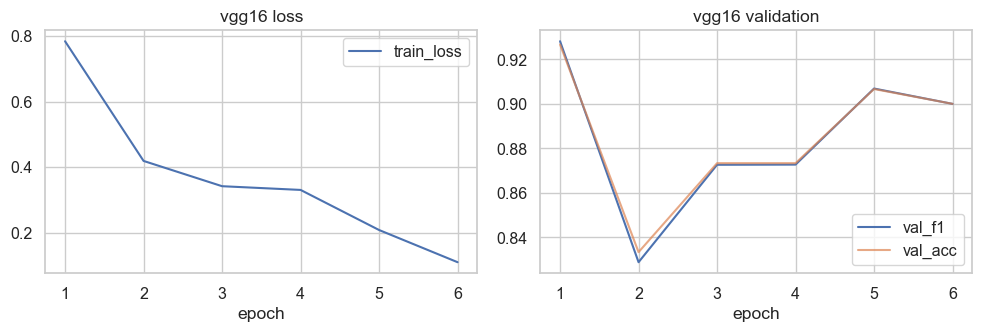

In [31]:
# Train: **vgg16** (Tier 0 — CNN)

MODEL_ID = "vgg16"
TIER = 0
RUN_SPLIT = True
RUN_CV = False
FORCE_RERUN = False

# ── Edit architecture here ─────────────────────────────────────────────────
ARCH = {"dropout": 0.3, "head_hidden": None}  # None or int e.g. 256

# Optional: fully custom model — set USE_CUSTOM_BUILD = True and define build_fn below
USE_CUSTOM_BUILD = False

if not USE_CUSTOM_BUILD:
    build_fn = make_tier0_build_fn(MODEL_ID, ARCH)
else:
    # def build_fn(tr_idx=None, va_idx=None):
    #     ... return model, train_ld, val_ld, test_ld, hybrid, fusion
    raise NotImplementedError("Define build_fn when USE_CUSTOM_BUILD is True")

summary = train_one_model(
    TIER, MODEL_ID, build_fn, LR_TIER0, BATCH_SIZE_TIER0,
    run_split=RUN_SPLIT, run_cv=RUN_CV, force_rerun=FORCE_RERUN,
)
plot_model_history(TIER, MODEL_ID, "split")



Tier 0 — resnet50
  [DONE] split resnet50  test_f1=0.9599


,tier,model,eval_mode,fold,acc,f1_macro,f1_weighted,precision_macro,recall_macro,fit_time_s
0,0,resnet50,split,,0.96,0.959942,NaN,NaN,NaN,147.03763



[split] 6e63e68f06d3
  test_f1_macro: 0.9599422544794208
  test_acc: 0.96
  fit_time_s: 147.03763008117676
  best_val_f1_macro: 0.9535894357743097


,epoch,train_loss,val_f1_macro,val_acc
11,12,0.062731,0.940445,0.940000
12,13,0.049362,0.926471,0.926667
13,14,0.045547,0.940063,0.940000
14,15,0.032935,0.907097,0.906667
15,16,0.011308,0.947148,0.946667



[cv5 fold 1] d25dcfbed33d
  val_f1_macro: 0.9501424501424501
  val_acc: 0.95
  fit_time_s: 179.66143202781677
  best_val_f1_macro: 0.9501424501424501


...

,epoch,train_loss,val_f1_macro,val_acc
5,6,0.132822,0.912612,0.912500
6,7,0.199972,0.910458,0.908333
7,8,0.112771,0.921319,0.920833
8,9,0.086452,0.929578,0.929167
9,10,0.055789,0.937968,0.937500



[cv5 fold 5] 7a81d4293bda
  val_f1_macro: 0.9457433372215306
  val_acc: 0.9458333333333333
  fit_time_s: 130.0842604637146
  best_val_f1_macro: 0.9457433372215306


,epoch,train_loss,val_f1_macro,val_acc
12,13,0.034306,0.945743,0.945833
13,14,0.003595,0.933345,0.933333
14,15,0.007712,0.941542,0.941667
15,16,0.002195,0.937533,0.937500
16,17,0.006513,0.941542,0.941667


Confusion matrix: results\phase3_cm_0_resnet50_split.csv


,Glioma,Meningioma,Pituitary Tumor
Glioma,94,5,1
Meningioma,2,95,3
Pituitary Tumor,0,1,99


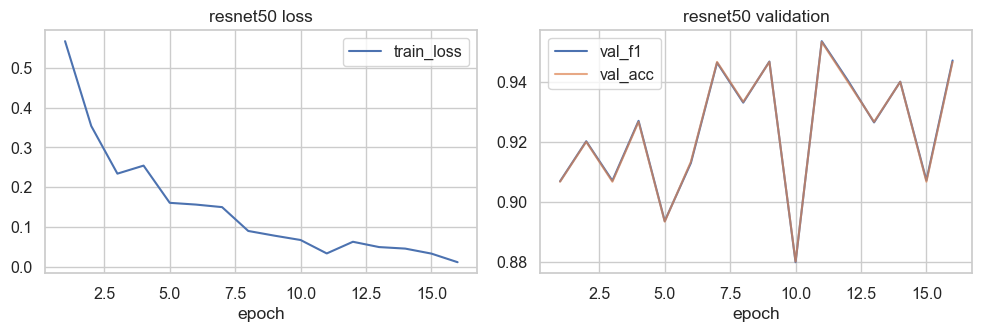

In [32]:
# Train: **resnet50** (Tier 0 — CNN)

MODEL_ID = "resnet50"
TIER = 0
RUN_SPLIT = True
RUN_CV = False
FORCE_RERUN = False

# ── Edit architecture here ─────────────────────────────────────────────────
ARCH = {"dropout": 0.3, "head_hidden": None}  # None or int e.g. 256

# Optional: fully custom model — set USE_CUSTOM_BUILD = True and define build_fn below
USE_CUSTOM_BUILD = False

if not USE_CUSTOM_BUILD:
    build_fn = make_tier0_build_fn(MODEL_ID, ARCH)
else:
    # def build_fn(tr_idx=None, va_idx=None):
    #     ... return model, train_ld, val_ld, test_ld, hybrid, fusion
    raise NotImplementedError("Define build_fn when USE_CUSTOM_BUILD is True")

summary = train_one_model(
    TIER, MODEL_ID, build_fn, LR_TIER0, BATCH_SIZE_TIER0,
    run_split=RUN_SPLIT, run_cv=RUN_CV, force_rerun=FORCE_RERUN,
)
plot_model_history(TIER, MODEL_ID, "split")



Tier 0 — efficientnet_b0
  [DONE] split efficientnet_b0  test_f1=0.9172


,tier,model,eval_mode,fold,acc,f1_macro,f1_weighted,precision_macro,recall_macro,fit_time_s
0,0,efficientnet_b0,split,,0.916667,0.917242,NaN,NaN,NaN,115.303856



[split] cbdefab7d16a
  test_f1_macro: 0.917241789509354
  test_acc: 0.9166666666666666
  fit_time_s: 115.30385637283325
  best_val_f1_macro: 0.9138134979077542


,epoch,train_loss,val_f1_macro,val_acc
5,6,0.228660,0.893504,0.893333
6,7,0.184727,0.887063,0.886667
7,8,0.142272,0.880720,0.880000
8,9,0.114900,0.901046,0.900000
9,10,0.091254,0.913518,0.913333



[cv5 fold 1] c9acded94548
  val_f1_macro: 0.9246796374433505
  val_acc: 0.925
  fit_time_s: 167.512065410614
  best_val_f1_macro: 0.9246796374433505


...

,epoch,train_loss,val_f1_macro,val_acc
11,12,0.093012,0.909432,0.908333
12,13,0.076240,0.917864,0.916667
13,14,0.118544,0.900998,0.900000
14,15,0.105540,0.930160,0.929167
15,16,0.065813,0.913498,0.912500



[cv5 fold 5] 1bb9fe2c709b
  val_f1_macro: 0.9291549297612686
  val_acc: 0.9291666666666667
  fit_time_s: 162.0479609966278
  best_val_f1_macro: 0.9291549297612686


,epoch,train_loss,val_f1_macro,val_acc
12,13,0.116998,0.916487,0.916667
13,14,0.100223,0.920354,0.920833
14,15,0.047727,0.912064,0.912500
15,16,0.069694,0.920510,0.920833
16,17,0.064569,0.907835,0.908333


Confusion matrix: results\phase3_cm_0_efficientnet_b0_split.csv


,Glioma,Meningioma,Pituitary Tumor
Glioma,85,14,1
Meningioma,0,96,4
Pituitary Tumor,1,5,94


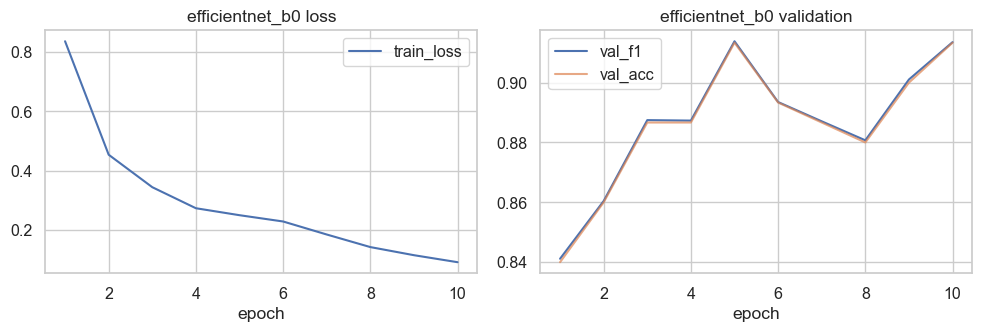

In [33]:
# Train: **efficientnet_b0** (Tier 0 — CNN)

MODEL_ID = "efficientnet_b0"
TIER = 0
RUN_SPLIT = True
RUN_CV = False
FORCE_RERUN = False

# ── Edit architecture here ─────────────────────────────────────────────────
ARCH = {"dropout": 0.3, "head_hidden": None}  # None or int e.g. 256

# Optional: fully custom model — set USE_CUSTOM_BUILD = True and define build_fn below
USE_CUSTOM_BUILD = False

if not USE_CUSTOM_BUILD:
    build_fn = make_tier0_build_fn(MODEL_ID, ARCH)
else:
    # def build_fn(tr_idx=None, va_idx=None):
    #     ... return model, train_ld, val_ld, test_ld, hybrid, fusion
    raise NotImplementedError("Define build_fn when USE_CUSTOM_BUILD is True")

summary = train_one_model(
    TIER, MODEL_ID, build_fn, LR_TIER0, BATCH_SIZE_TIER0,
    run_split=RUN_SPLIT, run_cv=RUN_CV, force_rerun=FORCE_RERUN,
)
plot_model_history(TIER, MODEL_ID, "split")



Tier 0 — vit_b_16
  [DONE] split vit_b_16  test_f1=0.8363


,tier,model,eval_mode,fold,acc,f1_macro,f1_weighted,precision_macro,recall_macro,fit_time_s
0,0,vit_b_16,split,,0.833333,0.836278,NaN,NaN,NaN,350.35932



[split] 5f69ef4d9e25
  test_f1_macro: 0.8362776195522197
  test_acc: 0.8333333333333334
  fit_time_s: 350.35931968688965
  best_val_f1_macro: 0.880113144914323


,epoch,train_loss,val_f1_macro,val_acc
4,5,0.564324,0.814376,0.813333
5,6,0.521537,0.830586,0.833333
6,7,0.567245,0.853861,0.853333
7,8,0.386304,0.832518,0.833333
8,9,0.383937,0.839652,0.840000



[cv5 fold 1] 7eb2a5f1afd3
  val_f1_macro: 0.920931004844507
  val_acc: 0.9208333333333333
  fit_time_s: 871.0758154392242
  best_val_f1_macro: 0.920931004844507


...

,epoch,train_loss,val_f1_macro,val_acc
9,10,0.114648,0.901097,0.900000
10,11,0.077066,0.889741,0.887500
11,12,0.049381,0.921710,0.920833
12,13,0.047617,0.938532,0.937500
13,14,0.024859,0.918113,0.916667



[cv5 fold 5] bd9eb3772004
  val_f1_macro: 0.9417403852186461
  val_acc: 0.9416666666666667
  fit_time_s: 637.365038394928
  best_val_f1_macro: 0.9417403852186461


,epoch,train_loss,val_f1_macro,val_acc
16,17,0.062919,0.916210,0.916667
17,18,0.036524,0.903192,0.904167
18,19,0.047314,0.929056,0.929167
19,20,0.029846,0.941628,0.941667
20,21,0.021636,0.916697,0.916667


Confusion matrix: results\phase3_cm_0_vit_b_16_split.csv


,Glioma,Meningioma,Pituitary Tumor
Glioma,83,17,0
Meningioma,12,84,4
Pituitary Tumor,1,16,83


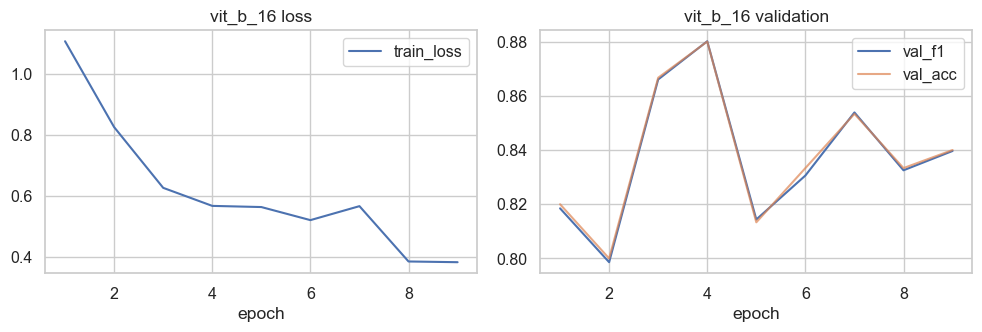

In [34]:
# Train: **vit_b_16** (Tier 0 — CNN)

MODEL_ID = "vit_b_16"
TIER = 0
RUN_SPLIT = True
RUN_CV = False
FORCE_RERUN = False

# ── Edit architecture here ─────────────────────────────────────────────────
ARCH = {"dropout": 0.3, "head_hidden": None}  # None or int e.g. 256

# Optional: fully custom model — set USE_CUSTOM_BUILD = True and define build_fn below
USE_CUSTOM_BUILD = False

if not USE_CUSTOM_BUILD:
    build_fn = make_tier0_build_fn(MODEL_ID, ARCH)
else:
    # def build_fn(tr_idx=None, va_idx=None):
    #     ... return model, train_ld, val_ld, test_ld, hybrid, fusion
    raise NotImplementedError("Define build_fn when USE_CUSTOM_BUILD is True")

summary = train_one_model(
    TIER, MODEL_ID, build_fn, LR_TIER0, BATCH_SIZE_TIER0,
    run_split=RUN_SPLIT, run_cv=RUN_CV, force_rerun=FORCE_RERUN,
)
plot_model_history(TIER, MODEL_ID, "split")


### Tier 1 — CNN + single handcrafted branch


Tier 1 — cnn_glcm
  [DONE] split cnn_glcm  test_f1=0.8873


,tier,model,eval_mode,fold,acc,f1_macro,f1_weighted,precision_macro,recall_macro,fit_time_s
0,1,cnn_glcm,split,,0.886667,0.887303,NaN,NaN,NaN,57.649297



[split] 353202f78e6a
  test_f1_macro: 0.8873028815583854
  test_acc: 0.8866666666666667
  fit_time_s: 57.64929676055908
  best_val_f1_macro: 0.8872923419231303


,epoch,train_loss,val_f1_macro,val_acc
7,8,1.846538,0.793849,0.793333
8,9,1.853405,0.837996,0.833333
9,10,1.818114,0.621836,0.673333
10,11,1.440037,0.866495,0.866667
11,12,0.906661,0.883126,0.886667



[cv5 fold 1] c81508d33b04
  val_f1_macro: 0.9130813483115121
  val_acc: 0.9125
  fit_time_s: 62.750219106674194
  best_val_f1_macro: 0.9130813483115121


...

,epoch,train_loss,val_f1_macro,val_acc
14,15,0.734438,0.845400,0.845833
15,16,0.578075,0.884170,0.883333
16,17,0.639347,0.768673,0.779167
17,18,0.438121,0.892522,0.891667
18,19,0.193349,0.882991,0.883333



[cv5 fold 5] 05e8d1ff71e1
  val_f1_macro: 0.9293974599697491
  val_acc: 0.9291666666666667
  fit_time_s: 87.88989329338074
  best_val_f1_macro: 0.9293974599697491


,epoch,train_loss,val_f1_macro,val_acc
16,17,0.172550,0.895189,0.895833
17,18,0.210286,0.868185,0.870833
18,19,0.322943,0.903796,0.904167
19,20,0.262726,0.881677,0.883333
20,21,0.120269,0.907853,0.908333


Confusion matrix: results\phase3_cm_1_cnn_glcm_split.csv


,Glioma,Meningioma,Pituitary Tumor
Glioma,86,12,2
Meningioma,3,88,9
Pituitary Tumor,1,7,92


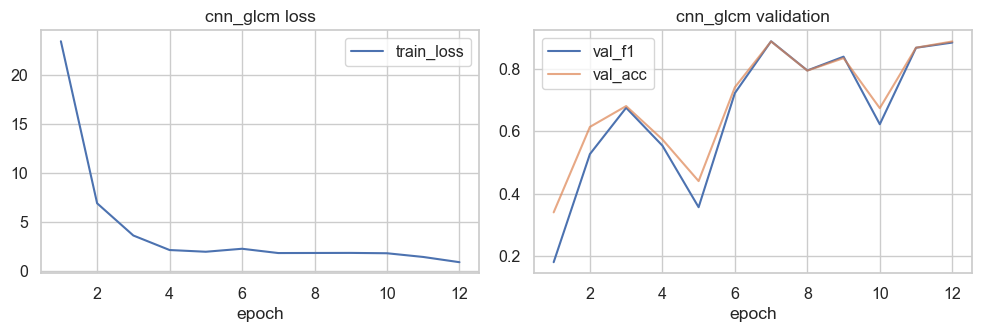

In [35]:
# Train: **cnn_glcm** (Tier 1 — Hybrid)

MODEL_ID = "cnn_glcm"
TIER = 1
RUN_SPLIT = True
RUN_CV = False
FORCE_RERUN = False

# ── Edit architecture here ─────────────────────────────────────────────────
ARCH = {"hand_embed": 128, "hand_hidden": None, "dropout": 0.3, "head_hidden": None, "pretrained_backbone": True}

# Optional: fully custom model — set USE_CUSTOM_BUILD = True and define build_fn below
USE_CUSTOM_BUILD = False

if not USE_CUSTOM_BUILD:
    build_fn = make_tier1_build_fn("glcm", ARCH)
else:
    # def build_fn(tr_idx=None, va_idx=None):
    #     ... return model, train_ld, val_ld, test_ld, hybrid, fusion
    raise NotImplementedError("Define build_fn when USE_CUSTOM_BUILD is True")

summary = train_one_model(
    TIER, MODEL_ID, build_fn, LR_HYBRID, BATCH_SIZE_HYBRID,
    run_split=RUN_SPLIT, run_cv=RUN_CV, force_rerun=FORCE_RERUN,
)
plot_model_history(TIER, MODEL_ID, "split")



Tier 1 — lbpnet
  [DONE] split lbpnet  test_f1=0.9331


,tier,model,eval_mode,fold,acc,f1_macro,f1_weighted,precision_macro,recall_macro,fit_time_s
0,1,lbpnet,split,,0.933333,0.93312,NaN,NaN,NaN,120.542902



[split] 3a5492d2982b
  test_f1_macro: 0.933119780915793
  test_acc: 0.9333333333333333
  fit_time_s: 120.54290199279785
  best_val_f1_macro: 0.960190136660725


,epoch,train_loss,val_f1_macro,val_acc
22,23,0.010362,0.953558,0.953333
23,24,0.022349,0.946917,0.946667
24,25,0.021363,0.940345,0.940000
25,26,0.010100,0.940345,0.940000
26,27,0.045131,0.953640,0.953333



[cv5 fold 1] 05d311a0ddd0
  val_f1_macro: 0.9292896876337183
  val_acc: 0.9291666666666667
  fit_time_s: 91.77286553382874
  best_val_f1_macro: 0.9292896876337183


...

,epoch,train_loss,val_f1_macro,val_acc
14,15,0.084815,0.917680,0.916667
15,16,0.060293,0.925415,0.925000
16,17,0.053032,0.921095,0.920833
17,18,0.050467,0.921927,0.920833
18,19,0.024409,0.917977,0.916667



[cv5 fold 5] 722c8c369415
  val_f1_macro: 0.8954740506841551
  val_acc: 0.8958333333333334
  fit_time_s: 45.64242935180664
  best_val_f1_macro: 0.8954740506841551


,epoch,train_loss,val_f1_macro,val_acc
6,7,0.195109,0.850632,0.850000
7,8,0.224600,0.889073,0.887500
8,9,0.192819,0.841386,0.845833
9,10,0.128136,0.881907,0.883333
10,11,0.058296,0.886562,0.887500


Confusion matrix: results\phase3_cm_1_lbpnet_split.csv


,Glioma,Meningioma,Pituitary Tumor
Glioma,93,5,2
Meningioma,5,90,5
Pituitary Tumor,1,2,97


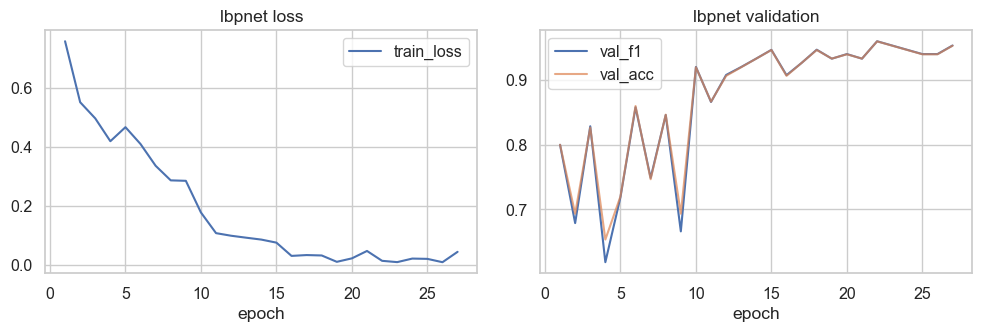

In [36]:
# Train: **lbpnet** (Tier 1 — Hybrid)

MODEL_ID = "lbpnet"
TIER = 1
RUN_SPLIT = True
RUN_CV = False
FORCE_RERUN = False

# ── Edit architecture here ─────────────────────────────────────────────────
ARCH = {"hand_embed": 128, "hand_hidden": None, "dropout": 0.3, "head_hidden": None, "pretrained_backbone": True}

# Optional: fully custom model — set USE_CUSTOM_BUILD = True and define build_fn below
USE_CUSTOM_BUILD = False

if not USE_CUSTOM_BUILD:
    build_fn = make_tier1_build_fn("lbp", ARCH)
else:
    # def build_fn(tr_idx=None, va_idx=None):
    #     ... return model, train_ld, val_ld, test_ld, hybrid, fusion
    raise NotImplementedError("Define build_fn when USE_CUSTOM_BUILD is True")

summary = train_one_model(
    TIER, MODEL_ID, build_fn, LR_HYBRID, BATCH_SIZE_HYBRID,
    run_split=RUN_SPLIT, run_cv=RUN_CV, force_rerun=FORCE_RERUN,
)
plot_model_history(TIER, MODEL_ID, "split")



Tier 1 — waveletcnn
  [DONE] split waveletcnn  test_f1=0.9467


,tier,model,eval_mode,fold,acc,f1_macro,f1_weighted,precision_macro,recall_macro,fit_time_s
0,1,waveletcnn,split,,0.946667,0.946683,NaN,NaN,NaN,80.426763



[split] 6dbc10a0deff
  test_f1_macro: 0.9466826606001865
  test_acc: 0.9466666666666667
  fit_time_s: 80.42676305770874
  best_val_f1_macro: 0.9058933539051358


,epoch,train_loss,val_f1_macro,val_acc
13,14,0.103166,0.868794,0.866667
14,15,0.078561,0.852279,0.853333
15,16,0.061303,0.874929,0.873333
16,17,0.027322,0.882216,0.880000
17,18,0.015684,0.893791,0.893333



[cv5 fold 1] e6a100925185
  val_f1_macro: 0.9124904597366194
  val_acc: 0.9125
  fit_time_s: 66.76448154449463
  best_val_f1_macro: 0.9124904597366194


...

,epoch,train_loss,val_f1_macro,val_acc
9,10,0.160713,0.924870,0.925000
10,11,0.128608,0.700582,0.716667
11,12,0.118777,0.930160,0.929167
12,13,0.073815,0.926434,0.925000
13,14,0.037132,0.890230,0.887500



[cv5 fold 5] ef984be50f2a
  val_f1_macro: 0.9248173673845484
  val_acc: 0.925
  fit_time_s: 50.18628716468811
  best_val_f1_macro: 0.9248173673845484


,epoch,train_loss,val_f1_macro,val_acc
7,8,0.169752,0.858971,0.862500
8,9,0.164104,0.900949,0.900000
9,10,0.162522,0.863248,0.862500
10,11,0.082375,0.924718,0.925000
11,12,0.035767,0.903811,0.904167


Confusion matrix: results\phase3_cm_1_waveletcnn_split.csv


,Glioma,Meningioma,Pituitary Tumor
Glioma,95,2,3
Meningioma,2,91,7
Pituitary Tumor,1,1,98


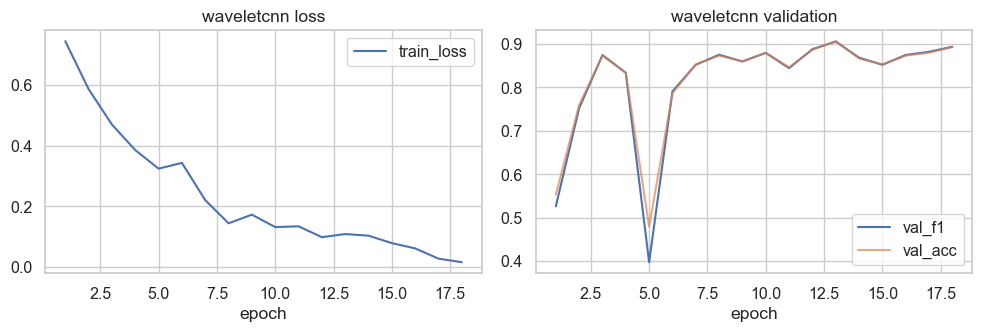

In [37]:
# Train: **waveletcnn** (Tier 1 — Hybrid)

MODEL_ID = "waveletcnn"
TIER = 1
RUN_SPLIT = True
RUN_CV = False
FORCE_RERUN = False

# ── Edit architecture here ─────────────────────────────────────────────────
ARCH = {"hand_embed": 128, "hand_hidden": None, "dropout": 0.3, "head_hidden": None, "pretrained_backbone": True}

# Optional: fully custom model — set USE_CUSTOM_BUILD = True and define build_fn below
USE_CUSTOM_BUILD = False

if not USE_CUSTOM_BUILD:
    build_fn = make_tier1_build_fn("dwt", ARCH)
else:
    # def build_fn(tr_idx=None, va_idx=None):
    #     ... return model, train_ld, val_ld, test_ld, hybrid, fusion
    raise NotImplementedError("Define build_fn when USE_CUSTOM_BUILD is True")

summary = train_one_model(
    TIER, MODEL_ID, build_fn, LR_HYBRID, BATCH_SIZE_HYBRID,
    run_split=RUN_SPLIT, run_cv=RUN_CV, force_rerun=FORCE_RERUN,
)
plot_model_history(TIER, MODEL_ID, "split")



Tier 1 — cnn_hog
  [DONE] split cnn_hog  test_f1=0.9361


,tier,model,eval_mode,fold,acc,f1_macro,f1_weighted,precision_macro,recall_macro,fit_time_s
0,1,cnn_hog,split,,0.936667,0.93609,NaN,NaN,NaN,102.938413



[split] 2d300f4c239f
  test_f1_macro: 0.9360895986539169
  test_acc: 0.9366666666666666
  fit_time_s: 102.93841338157654
  best_val_f1_macro: 0.94


,epoch,train_loss,val_f1_macro,val_acc
18,19,0.015353,0.920424,0.920000
19,20,0.015598,0.926776,0.926667
20,21,0.002858,0.939997,0.940000
21,22,0.006563,0.920424,0.920000
22,23,0.005443,0.927013,0.926667



[cv5 fold 1] c0f2c1a78d9a
  val_f1_macro: 0.9456437452308398
  val_acc: 0.9458333333333333
  fit_time_s: 117.4093668460846
  best_val_f1_macro: 0.9456437452308398


...

,epoch,train_loss,val_f1_macro,val_acc
15,16,0.075776,0.905848,0.904167
16,17,0.054739,0.886015,0.883333
17,18,0.037953,0.917149,0.916667
18,19,0.023473,0.910086,0.908333
19,20,0.006232,0.902112,0.900000



[cv5 fold 5] ea2d6411c470
  val_f1_macro: 0.9455177586716607
  val_acc: 0.9458333333333333
  fit_time_s: 93.62187337875366
  best_val_f1_macro: 0.9455177586716607


,epoch,train_loss,val_f1_macro,val_acc
17,18,0.026698,0.884951,0.887500
18,19,0.011408,0.929453,0.929167
19,20,0.011030,0.913104,0.912500
20,21,0.020763,0.928841,0.929167
21,22,0.016789,0.912496,0.912500


Confusion matrix: results\phase3_cm_1_cnn_hog_split.csv


,Glioma,Meningioma,Pituitary Tumor
Glioma,96,3,1
Meningioma,7,87,6
Pituitary Tumor,1,1,98


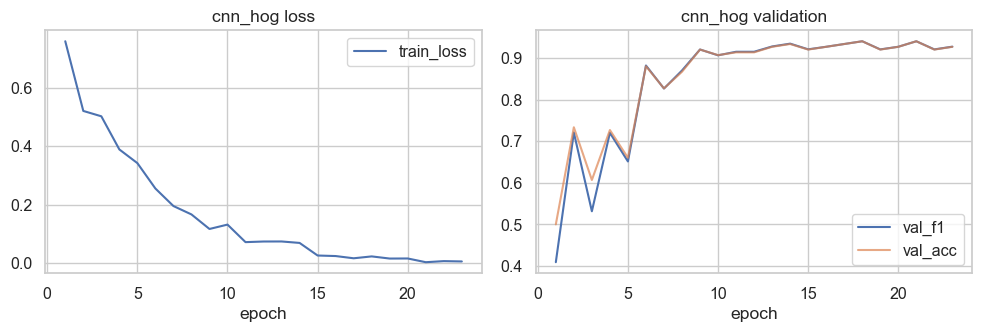

In [38]:
# Train: **cnn_hog** (Tier 1 — Hybrid)

MODEL_ID = "cnn_hog"
TIER = 1
RUN_SPLIT = True
RUN_CV = False
FORCE_RERUN = False

# ── Edit architecture here ─────────────────────────────────────────────────
ARCH = {"hand_embed": 128, "hand_hidden": None, "dropout": 0.3, "head_hidden": None, "pretrained_backbone": True}

# Optional: fully custom model — set USE_CUSTOM_BUILD = True and define build_fn below
USE_CUSTOM_BUILD = False

if not USE_CUSTOM_BUILD:
    build_fn = make_tier1_build_fn("hog", ARCH)
else:
    # def build_fn(tr_idx=None, va_idx=None):
    #     ... return model, train_ld, val_ld, test_ld, hybrid, fusion
    raise NotImplementedError("Define build_fn when USE_CUSTOM_BUILD is True")

summary = train_one_model(
    TIER, MODEL_ID, build_fn, LR_HYBRID, BATCH_SIZE_HYBRID,
    run_split=RUN_SPLIT, run_cv=RUN_CV, force_rerun=FORCE_RERUN,
)
plot_model_history(TIER, MODEL_ID, "split")


### Tier 2 — Multi-branch fusion


Tier 2 — multibranch_fusion
  [DONE] split multibranch_fusion  test_f1=0.8799


,tier,model,eval_mode,fold,acc,f1_macro,f1_weighted,precision_macro,recall_macro,fit_time_s
0,2,multibranch_fusion,split,,0.88,0.879931,NaN,NaN,NaN,74.597714



[split] 36812bb56e03
  test_f1_macro: 0.8799309149395401
  test_acc: 0.88
  fit_time_s: 74.59771418571472
  best_val_f1_macro: 0.9333033063090115


,epoch,train_loss,val_f1_macro,val_acc
6,7,0.855744,0.893146,0.893333
7,8,0.894719,0.783608,0.786667
8,9,0.820930,0.868896,0.866667
9,10,0.522820,0.867837,0.873333
10,11,0.465335,0.831438,0.826667



[cv5 fold 1] 0f7d007ca6ab
  val_f1_macro: 0.9378881987577641
  val_acc: 0.9375
  fit_time_s: 211.57912230491638
  best_val_f1_macro: 0.9378881987577641


...

,epoch,train_loss,val_f1_macro,val_acc
12,13,0.382647,0.872866,0.870833
13,14,0.437950,0.866787,0.866667
14,15,0.466115,0.854745,0.854167
15,16,0.172220,0.855070,0.854167
16,17,0.227373,0.867733,0.866667



[cv5 fold 5] 019077bca7f7
  val_f1_macro: 0.9161020150313263
  val_acc: 0.9166666666666666
  fit_time_s: 137.38994359970093
  best_val_f1_macro: 0.9161020150313263


,epoch,train_loss,val_f1_macro,val_acc
15,16,0.236764,0.908226,0.908333
16,17,0.130631,0.903663,0.904167
17,18,0.167313,0.899780,0.900000
18,19,0.132377,0.907877,0.908333
19,20,0.106296,0.907677,0.908333


Confusion matrix: results\phase3_cm_2_multibranch_fusion_split.csv


,Glioma,Meningioma,Pituitary Tumor
Glioma,88,11,1
Meningioma,11,83,6
Pituitary Tumor,2,5,93


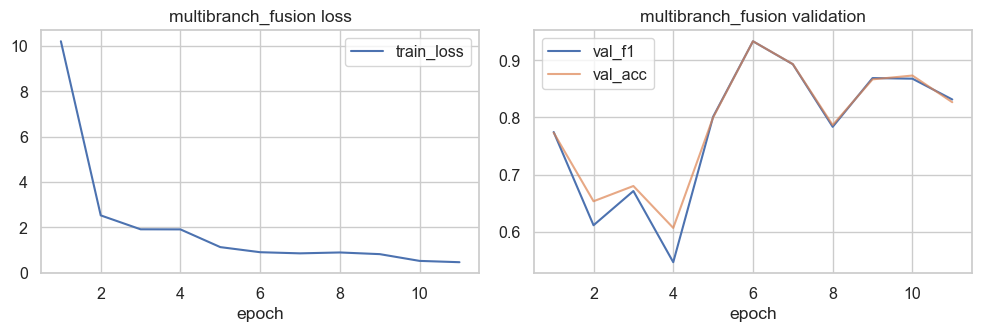

In [39]:
# Train: **multibranch_fusion** (Tier 2 — Fusion)

MODEL_ID = "multibranch_fusion"
TIER = 2
RUN_SPLIT = True
RUN_CV = False
FORCE_RERUN = False

# ── Edit architecture here ─────────────────────────────────────────────────
ARCH = {"embed": 64, "branch_hidden": None, "dropout": 0.3, "head_hidden": None, "pretrained_backbone": True}

# Optional: fully custom model — set USE_CUSTOM_BUILD = True and define build_fn below
USE_CUSTOM_BUILD = False

if not USE_CUSTOM_BUILD:
    build_fn = make_tier2_build_fn("multibranch_fusion", ARCH)
else:
    # def build_fn(tr_idx=None, va_idx=None):
    #     ... return model, train_ld, val_ld, test_ld, hybrid, fusion
    raise NotImplementedError("Define build_fn when USE_CUSTOM_BUILD is True")

summary = train_one_model(
    TIER, MODEL_ID, build_fn, LR_HYBRID, BATCH_SIZE_FUSION,
    run_split=RUN_SPLIT, run_cv=RUN_CV, force_rerun=FORCE_RERUN,
)
plot_model_history(TIER, MODEL_ID, "split")



Tier 2 — attention_fusion
  [DONE] split attention_fusion  test_f1=0.9107


,tier,model,eval_mode,fold,acc,f1_macro,f1_weighted,precision_macro,recall_macro,fit_time_s
0,2,attention_fusion,split,,0.91,0.91066,NaN,NaN,NaN,104.736129



[split] b65c6a9f27de
  test_f1_macro: 0.9106599832915622
  test_acc: 0.91
  fit_time_s: 104.73612880706787
  best_val_f1_macro: 0.8946986158055689


,epoch,train_loss,val_f1_macro,val_acc
9,10,0.150129,0.878639,0.880000
10,11,0.195092,0.864359,0.866667
11,12,0.172512,0.867239,0.866667
12,13,0.102285,0.853019,0.853333
13,14,0.076532,0.893656,0.893333



[cv5 fold 1] 9f66d183d2df
  val_f1_macro: 0.9456107852217762
  val_acc: 0.9458333333333333
  fit_time_s: 208.22445702552795
  best_val_f1_macro: 0.9456107852217762


...

,epoch,train_loss,val_f1_macro,val_acc
5,6,1.178827,0.505457,0.566667
6,7,1.008980,0.719578,0.729167
7,8,0.957328,0.689350,0.695833
8,9,0.738063,0.799640,0.795833
9,10,0.610480,0.671056,0.687500



[cv5 fold 5] 82c7d498cd07
  val_f1_macro: 0.9201898376427162
  val_acc: 0.9208333333333333
  fit_time_s: 125.47511148452759
  best_val_f1_macro: 0.9201898376427162


,epoch,train_loss,val_f1_macro,val_acc
13,14,0.137970,0.894647,0.895833
14,15,0.094583,0.907071,0.908333
15,16,0.068444,0.916960,0.916667
16,17,0.078096,0.920023,0.920833
17,18,0.050251,0.916271,0.916667


Confusion matrix: results\phase3_cm_2_attention_fusion_split.csv


,Glioma,Meningioma,Pituitary Tumor
Glioma,87,13,0
Meningioma,2,92,6
Pituitary Tumor,1,5,94


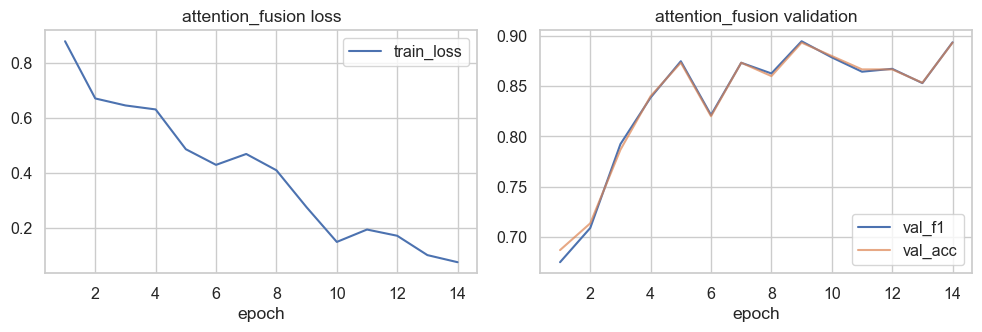

In [40]:
# Train: **attention_fusion** (Tier 2 — Fusion)

MODEL_ID = "attention_fusion"
TIER = 2
RUN_SPLIT = True
RUN_CV = False
FORCE_RERUN = False

# ── Edit architecture here ─────────────────────────────────────────────────
ARCH = {"embed": 64, "branch_hidden": None, "dropout": 0.3, "head_hidden": None, "pretrained_backbone": True}

# Optional: fully custom model — set USE_CUSTOM_BUILD = True and define build_fn below
USE_CUSTOM_BUILD = False

if not USE_CUSTOM_BUILD:
    build_fn = make_tier2_build_fn("attention_fusion", ARCH)
else:
    # def build_fn(tr_idx=None, va_idx=None):
    #     ... return model, train_ld, val_ld, test_ld, hybrid, fusion
    raise NotImplementedError("Define build_fn when USE_CUSTOM_BUILD is True")

summary = train_one_model(
    TIER, MODEL_ID, build_fn, LR_HYBRID, BATCH_SIZE_FUSION,
    run_split=RUN_SPLIT, run_cv=RUN_CV, force_rerun=FORCE_RERUN,
)
plot_model_history(TIER, MODEL_ID, "split")


## Section 9 — Finalize metrics export

Run after training the models you care about (merges all rows in `PHASE3_METRICS_ROWS`).

In [41]:
PHASE3_ALL_DF = pd.DataFrame(PHASE3_METRICS_ROWS)
PHASE3_ALL_DF.to_csv(RESULTS_DIR / "phase3_all_metrics.csv", index=False)
joblib.dump(PHASE3_ALL_DF, PHASE_CACHE_DIR / "phase3_all_metrics_df.pkl")
print("Saved", RESULTS_DIR / "phase3_all_metrics.csv")
display(PHASE3_ALL_DF.sort_values(["tier", "model", "eval_mode"]))


Saved results\phase3_all_metrics.csv


,tier,model,eval_mode,fold,acc,f1_macro,f1_weighted,precision_macro,recall_macro,fit_time_s
2,0,efficientnet_b0,split,,0.916667,0.917242,NaN,NaN,NaN,115.303856
1,0,resnet50,split,,0.960000,0.959942,NaN,NaN,NaN,147.037630
0,0,vgg16,split,,0.876667,0.879370,NaN,NaN,NaN,65.920622
3,0,vit_b_16,split,,0.833333,0.836278,NaN,NaN,NaN,350.359320
4,1,cnn_glcm,split,,0.886667,0.887303,NaN,NaN,NaN,57.649297
7,1,cnn_hog,split,,0.936667,0.936090,NaN,NaN,NaN,102.938413
5,1,lbpnet,split,,0.933333,0.933120,NaN,NaN,NaN,120.542902
6,1,waveletcnn,split,,0.946667,0.946683,NaN,NaN,NaN,80.426763
9,2,attention_fusion,split,,0.910000,0.910660,NaN,NaN,NaN,104.736129
8,2,multibranch_fusion,split,,0.880000,0.879931,NaN,NaN,NaN,74.597714


## Section 10 — Comparison with Phase 2 ML & VLM

Saved results\phase3_vs_phase2_comparison.csv


,dl_model,dl_tier,dl_f1_macro,dl_acc,phase2_feature_set,phase2_best_model,phase2_f1_macro,phase2_acc,delta_f1_dl_minus_p2
0,vgg16,0,0.879370,0.876667,,,NaN,NaN,NaN
1,resnet50,0,0.959942,0.960000,,,NaN,NaN,NaN
2,efficientnet_b0,0,0.917242,0.916667,,,NaN,NaN,NaN
3,vit_b_16,0,0.836278,0.833333,,,NaN,NaN,NaN
4,cnn_glcm,1,0.887303,0.886667,B — Tex(opt),RF,0.811799,0.813333,0.075504
5,lbpnet,1,0.933120,0.933333,B — Tex(opt),RF,0.811799,0.813333,0.121321
6,waveletcnn,1,0.946683,0.946667,C — DWT(opt),SVM,0.741493,0.743333,0.205189
7,cnn_hog,1,0.936090,0.936667,D — HOG,KNN,0.899449,0.900000,0.036641
8,multibranch_fusion,2,0.879931,0.880000,Full(opt),SVM,0.929943,0.930000,-0.050012
9,attention_fusion,2,0.910660,0.910000,Full(opt),SVM,0.929943,0.930000,-0.019283



VLM test metrics:


,Class,Precision,Recall,F1-score,Support
0,Glioma,0.890110,0.81,0.848168,100
1,Meningioma,0.775862,0.90,0.833333,100
2,Pituitary Tumor,0.956989,0.89,0.922280,100
3,Overall Accuracy,NaN,NaN,0.866667,300


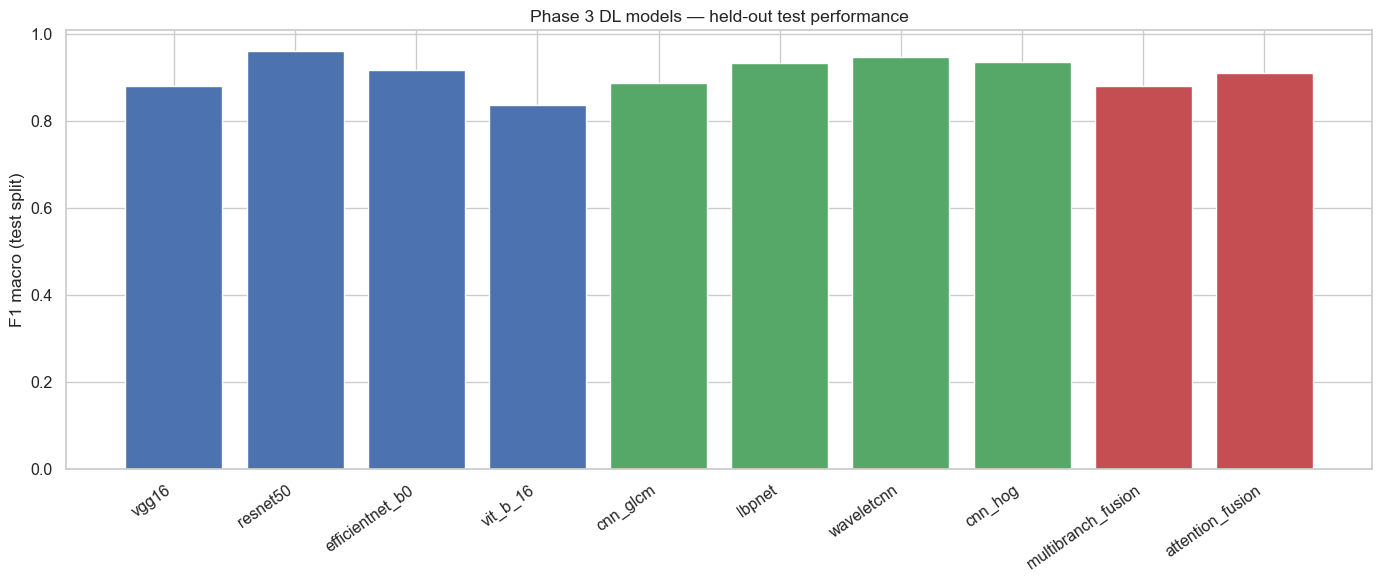

Saved figures\phase3_tier_comparison.png


In [42]:
P2_PATHS = [
    Path("phase2_all_modes_metrics.csv"),
    PHASE_CACHE_DIR / "phase2_all_metrics_df.pkl",
]
p2 = None
for p in P2_PATHS:
    if p.suffix == ".csv" and p.exists():
        p2 = pd.read_csv(p)
        break
    if p.suffix == ".pkl" and p.exists():
        p2 = joblib.load(p)
        break

if p2 is None:
    print("Phase 2 metrics not found — run Projet7 Phase 2 first.")
else:
    p2_split = p2[p2["eval_mode"] == "split"].copy()
    phase2_map = {
        "cnn_glcm": "B — Tex(opt)",
        "lbpnet": "B — Tex(opt)",
        "waveletcnn": "C — DWT(opt)",
        "cnn_hog": "D — HOG",
        "multibranch_fusion": "Full(opt)",
        "attention_fusion": "Full(opt)",
    }
    p3_split = PHASE3_ALL_DF[PHASE3_ALL_DF["eval_mode"] == "split"].copy()

    rows = []
    for _, r in p3_split.iterrows():
        mid = r["model"]
        fs = phase2_map.get(mid)
        p2_rows = p2_split[p2_split["feature_set"] == fs] if fs else pd.DataFrame()
        best_p2 = None
        if len(p2_rows):
            best_p2 = p2_rows.loc[p2_rows["f1_macro"].idxmax()]
        rows.append({
            "dl_model": mid,
            "dl_tier": r["tier"],
            "dl_f1_macro": r["f1_macro"],
            "dl_acc": r["acc"],
            "phase2_feature_set": fs or "",
            "phase2_best_model": best_p2["model"] if best_p2 is not None else "",
            "phase2_f1_macro": best_p2["f1_macro"] if best_p2 is not None else np.nan,
            "phase2_acc": best_p2["acc"] if best_p2 is not None else np.nan,
            "delta_f1_dl_minus_p2": (
                r["f1_macro"] - best_p2["f1_macro"] if best_p2 is not None else np.nan
            ),
        })
    cmp_df = pd.DataFrame(rows)
    cmp_df.to_csv(RESULTS_DIR / "phase3_vs_phase2_comparison.csv", index=False)
    print("Saved", RESULTS_DIR / "phase3_vs_phase2_comparison.csv")
    display(cmp_df)

# VLM reference
vlm_path = RESULTS_DIR / "vlm_test_metrics.csv"
if vlm_path.exists():
    vlm = pd.read_csv(vlm_path)
    print("\nVLM test metrics:")
    display(vlm)
else:
    print("VLM metrics not found at", vlm_path)

# Bar chart — split eval, all tiers
plot_df = PHASE3_ALL_DF[PHASE3_ALL_DF["eval_mode"].isin(["split", "cv5_mean"])].copy()
fig, ax = plt.subplots(figsize=(14, 6))
sub = plot_df[plot_df["eval_mode"] == "split"]
colors = {0: "#4C72B0", 1: "#55A868", 2: "#C44E52"}
ax.bar(
    sub["model"],
    sub["f1_macro"],
    color=[colors.get(t, "#8172B2") for t in sub["tier"]],
)
ax.set_xticklabels(sub["model"], rotation=35, ha="right")
ax.set_ylabel("F1 macro (test split)")
ax.set_title("Phase 3 DL models — held-out test performance")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "phase3_tier_comparison.png", dpi=200)
plt.show()
print("Saved", FIGURES_DIR / "phase3_tier_comparison.png")
